# 💳 Credit Risk Prediction System

---

# 📌 Project Overview

This project aims to build an AI-powered Credit Risk Prediction System using Machine Learning techniques.

The system analyzes customers' financial and personal information to predict whether a customer is:

- ✅ Low Risk Customer
- ⚠️ High Risk Customer

This solution helps banks and financial institutions make faster and more accurate loan approval decisions.

---

# 🎯 Project Objective

The main goal of this project is to:

✔ Analyze customer financial behavior  
✔ Predict loan default risk  
✔ Reduce financial losses  
✔ Improve loan approval decisions  
✔ Automate credit risk assessment using AI  

---

# 🗂 Dataset Information

The dataset contains customers' financial and personal information such as:

| Feature | Description |
|---|---|
| person_age | Customer age |
| person_income | Annual income |
| person_emp_length | Employment length |
| person_home_ownership | Home ownership type |
| loan_intent | Loan purpose |
| loan_grade | Loan grade |
| loan_amnt | Loan amount |
| loan_int_rate | Interest rate |
| loan_percent_income | Loan-to-income ratio |
| cb_person_default_on_file | Historical default record |
| cb_person_cred_hist_length | Credit history length |

---

# 🎯 Target Variable

| Target | Meaning |
|---|---|
| 0 | ✅ Low Risk |
| 1 | ⚠️ High Risk |

---

# ⚙️ Project Workflow

```text
Data Cleaning
        ↓
Encoding
        ↓
Feature Scaling
        ↓
EDA & Visualization
        ↓
Model Training
        ↓
Hyperparameter Tuning
        ↓
Model Evaluation
        ↓
Deployment using Streamlit

### Import Libraries

In [84]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import pickle
import sys
!{sys.executable} -m pip install lightgbm
import sys
!{sys.executable} -m pip install imbalanced-learn
warnings.filterwarnings('ignore')



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Read File

In [85]:
df=pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Data Cleaning

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [87]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [88]:
df.shape

(32581, 12)

In [89]:
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [90]:
df['loan_int_rate'].fillna(df['loan_int_rate'].mean(), inplace=True)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [92]:
n_before = len(df)
df = df[df['person_age'] <= 100].copy()
n_before - len(df)
df['person_age'].max()

np.int64(94)

In [93]:
n_before = len(df)
df = df[df['person_emp_length'] <= 60].copy()
{n_before - len(df)}


{2}

In [94]:
df.duplicated().sum()

np.int64(165)

In [95]:
df.drop_duplicates(inplace=True)

In [96]:
df.duplicated().sum(),df.isnull().sum().sum()

(np.int64(0), np.int64(0))

### Train-Test Split

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
x=df.drop('loan_status', axis=1)
y=df['loan_status']

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

### Encoding

In [100]:
from sklearn.preprocessing import LabelEncoder , StandardScaler ,OneHotEncoder
le=LabelEncoder()
sc=StandardScaler()


In [101]:
df['cb_person_default_on_file'].unique()

array(['N', 'Y'], dtype=object)

In [102]:
col=['loan_intent','loan_grade']
for i in col:
    x_train[i]=le.fit_transform(x_train[i])
    x_test[i]=le.transform(x_test[i])
    with open(f'{i}_label_encoder.pkl', 'wb') as f:
        pickle.dump(le, f)

In [103]:
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_intent',
    'loan_grade',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

sc.fit(x_train[num_cols])

x_train[num_cols] = sc.transform(x_train[num_cols])
x_test[num_cols] = sc.transform(x_test[num_cols])

with open('scaler.pkl', 'wb') as f:
    pickle.dump(sc, f)

In [104]:
col2=['person_home_ownership','cb_person_default_on_file']


In [105]:
encoders = {}

for coll in col2:
  
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    train_encoded = ohe.fit_transform(x_train[[coll]])
    test_encoded = ohe.transform(x_test[[coll]])
    
    
    train_df = pd.DataFrame(
        train_encoded,
        columns=ohe.get_feature_names_out([coll]),
        index=x_train.index
    )
    
    test_df = pd.DataFrame(
        test_encoded,
        columns=ohe.get_feature_names_out([coll]),
        index=x_test.index
    )
    
   
    x_train.drop(coll, axis=1, inplace=True)
    x_test.drop(coll, axis=1, inplace=True)
    
    
    x_train = pd.concat([x_train, train_df], axis=1)
    x_test = pd.concat([x_test, test_df], axis=1)
    
    
    encoders[coll] = ohe
    with open(f"{coll}_ohe.pkl", "wb") as f:
        pickle.dump(ohe, f)

In [106]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25927 entries, 28365 to 23782
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      25927 non-null  float64
 1   person_income                   25927 non-null  float64
 2   person_emp_length               25927 non-null  float64
 3   loan_intent                     25927 non-null  float64
 4   loan_grade                      25927 non-null  float64
 5   loan_amnt                       25927 non-null  float64
 6   loan_int_rate                   25927 non-null  float64
 7   loan_percent_income             25927 non-null  float64
 8   cb_person_cred_hist_length      25927 non-null  float64
 9   person_home_ownership_MORTGAGE  25927 non-null  float64
 10  person_home_ownership_OTHER     25927 non-null  float64
 11  person_home_ownership_OWN       25927 non-null  float64
 12  person_home_ownership_RENT      2

### EDA & Visualization

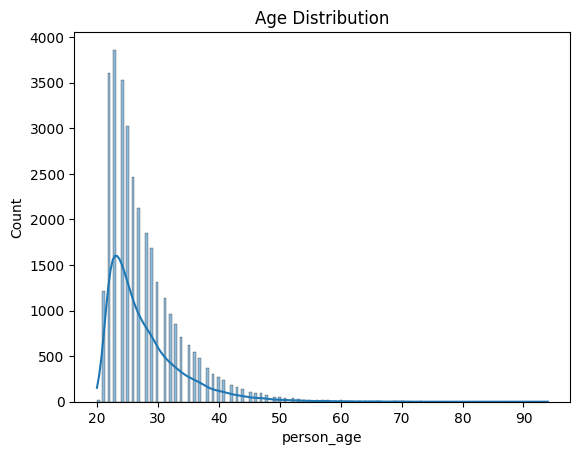

In [107]:
plt.figure()
sns.histplot(df['person_age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [108]:
df['person_age'].skew()

np.float64(1.9423593283661278)

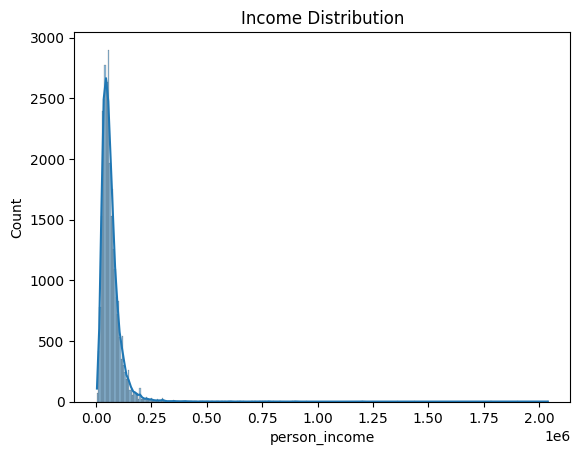

In [109]:
plt.figure()
sns.histplot(df['person_income'], kde=True)
plt.title("Income Distribution")
plt.show()

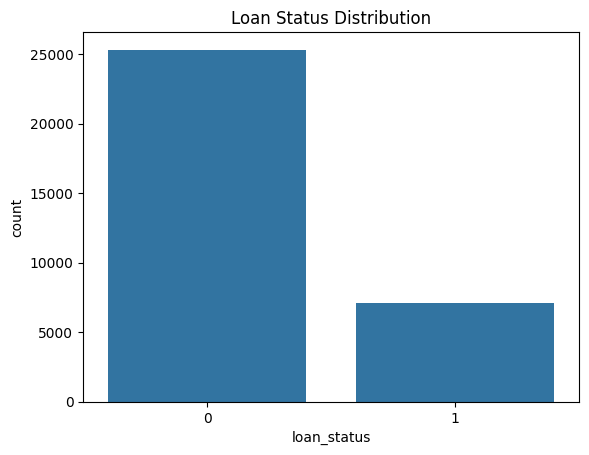

In [110]:
plt.figure()
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

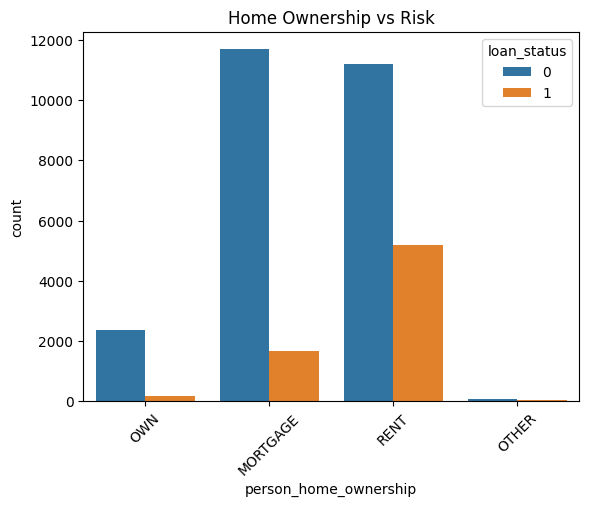

In [111]:
plt.figure()
sns.countplot(x='person_home_ownership', hue='loan_status', data=df)
plt.xticks(rotation=45)
plt.title("Home Ownership vs Risk")
plt.show()

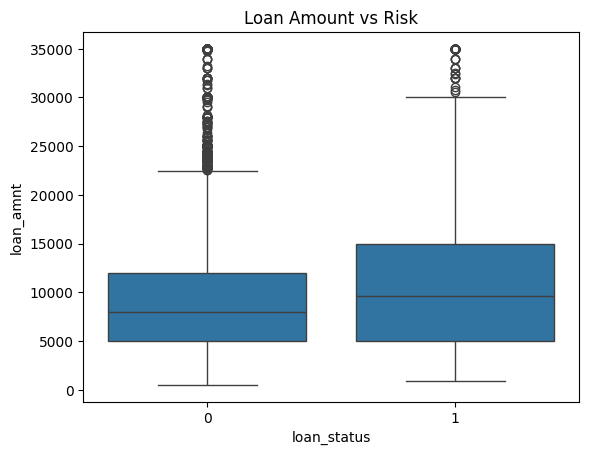

In [112]:
plt.figure()
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title("Loan Amount vs Risk")
plt.show()

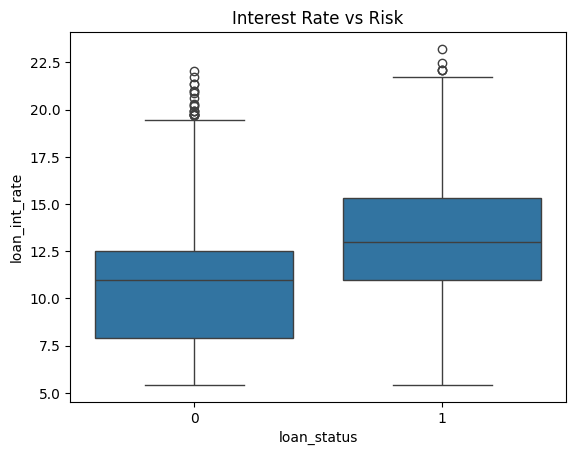

In [113]:
plt.figure()
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)
plt.title("Interest Rate vs Risk")
plt.show()

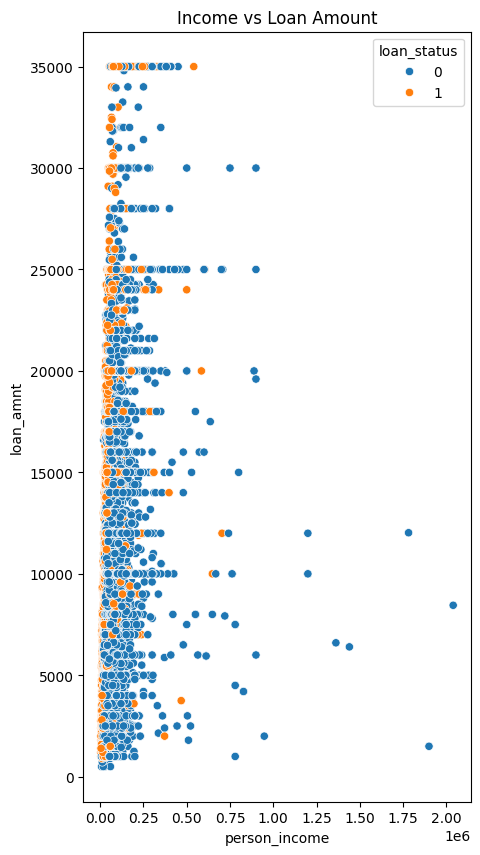

In [114]:
plt.figure(figsize=(5,10))
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df)
plt.title("Income vs Loan Amount")
plt.show()

<Axes: >

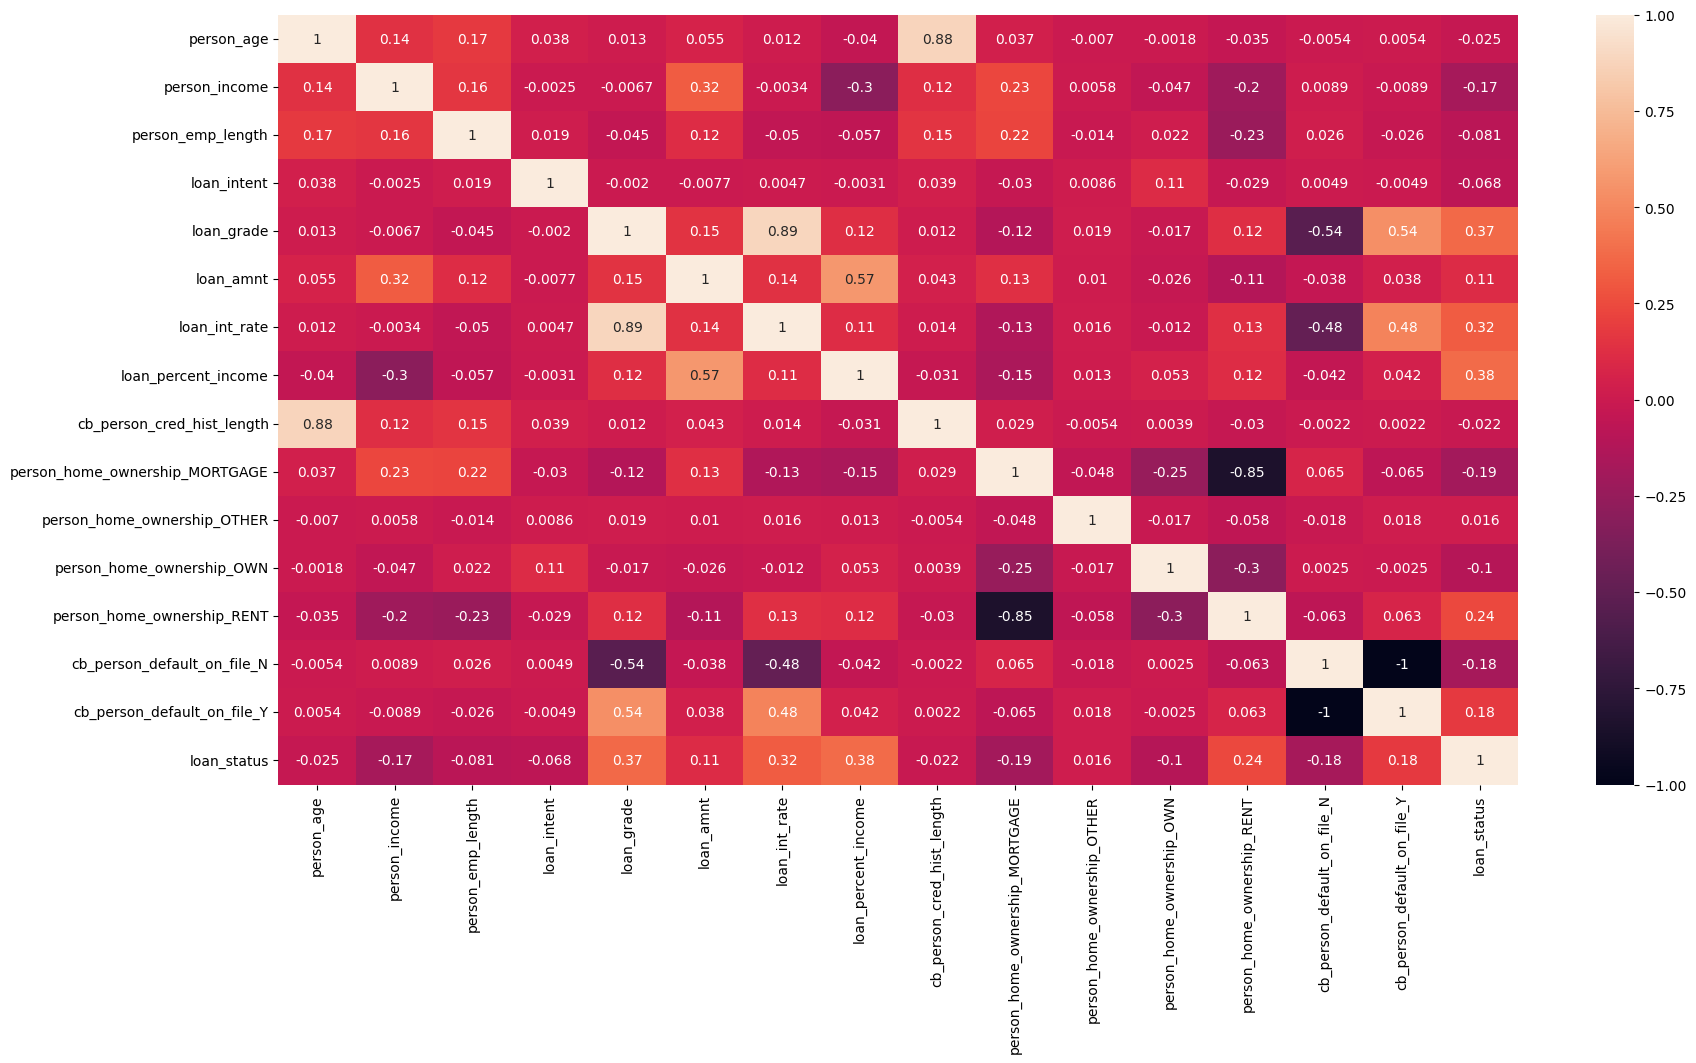

In [115]:
plt.figure(figsize=(20,10))
sns.heatmap(pd.concat([x_train,pd.Series(y_train,name='loan_status')],axis=1).corr(),annot=True)

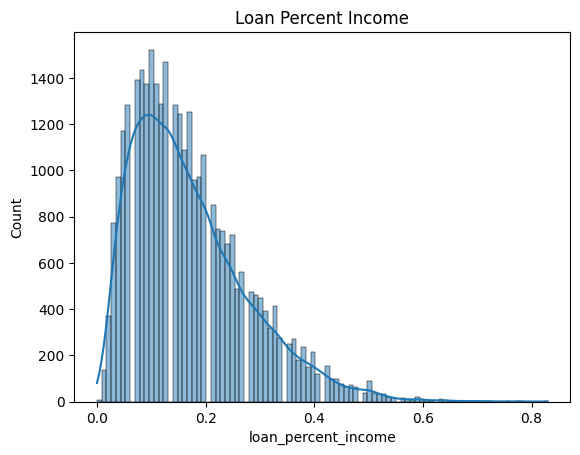

In [116]:
plt.figure()
sns.histplot(df['loan_percent_income'], kde=True)
plt.title("Loan Percent Income")
plt.show()

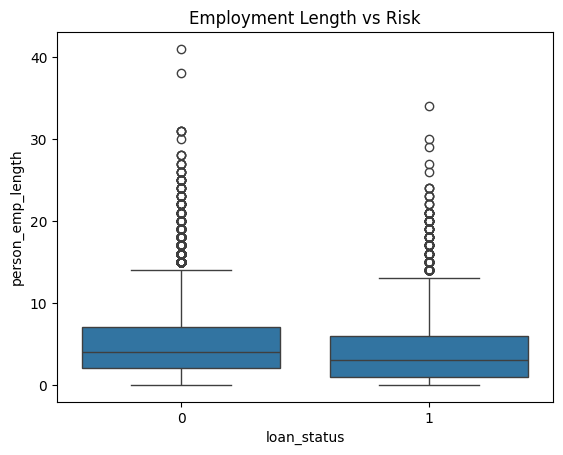

In [117]:
plt.figure()
sns.boxplot(x='loan_status', y='person_emp_length', data=df)
plt.title("Employment Length vs Risk")
plt.show()

In [118]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)
print("x_train_smote = ",x_train_smote.shape ," y_train_smote = ", y_train_smote.shape)

x_train_smote =  (40522, 15)  y_train_smote =  (40522,)


In [119]:
y_train_smote.value_counts()

loan_status
0    20261
1    20261
Name: count, dtype: int64

### Model Training

In [120]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score , f1_score,precision_score, recall_score, roc_auc_score

In [121]:
model_lr = LogisticRegression()
model_lr.fit(x_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [122]:
y_pred_lr = model_lr.predict(x_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression Accuracy Score:")
print(accuracy_score(y_test, y_pred_lr))
print("Logistic Regression F1 Score:")
print("F1 score:", f1_score(y_test, y_pred_lr))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      5060
           1       0.51      0.77      0.61      1422

    accuracy                           0.79      6482
   macro avg       0.72      0.78      0.73      6482
weighted avg       0.83      0.79      0.80      6482

Logistic Regression Accuracy Score:
0.787102746066029
Logistic Regression F1 Score:
F1 score: 0.6138780078343593


In [123]:
from sklearn.neighbors import KNeighborsClassifier


In [124]:
knn = KNeighborsClassifier(n_neighbors=9, metric='minkowski',p=1)
knn.fit(x_train_smote, y_train_smote)
y_pred_knn = knn.predict(x_test)


In [125]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89      5060
           1       0.60      0.77      0.68      1422

    accuracy                           0.84      6482
   macro avg       0.77      0.81      0.78      6482
weighted avg       0.86      0.84      0.84      6482



In [126]:
print("KNN Accuracy Score:")
print(accuracy_score(y_test, y_pred_knn))
print("KNN F1 Score:")
print("F1 score:", f1_score(y_test, y_pred_knn))
print("KNN Precision Score:")
print("Precision score:")
print(precision_score(y_test, y_pred_knn))
print("KNN Recall Score:")
print("Recall score:", recall_score(y_test, y_pred_knn))

KNN Accuracy Score:
0.8381672323356989
KNN F1 Score:
F1 score: 0.6771314250538627
KNN Precision Score:
Precision score:
0.60207991242474
KNN Recall Score:
Recall score: 0.7735583684950773


### Grid Shearch

In [127]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


In [128]:
model_rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
}
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=5, scoring='f1')
grid_search.fit(x_train_smote, y_train_smote)


# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [129]:
best_score = grid_search.best_score_
print("Best Score:", best_score)

Best Score: 0.9447395562616018


In [130]:
model_rf_best = RandomForestClassifier(**best_params, random_state=42)
model_rf_best.fit(x_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [131]:

y_pred_rf = model_rf_best.predict(x_test)   


In [132]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Accuracy Score:")
print(accuracy_score(y_test, y_pred_rf))
print("Random Forest F1 Score:")
print("F1 score:", f1_score(y_test, y_pred_rf))
print("Random Forest Precision Score:")
print("Precision score:", precision_score(y_test, y_pred_rf))
print("Random Forest Recall Score:")
print("Recall score:", recall_score(y_test, y_pred_rf))
print("Random Forest ROC AUC Score:")
print("ROC AUC score:", roc_auc_score(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      5060
           1       0.90      0.74      0.81      1422

    accuracy                           0.92      6482
   macro avg       0.91      0.86      0.88      6482
weighted avg       0.92      0.92      0.92      6482

Random Forest Accuracy Score:
0.9245603208886146
Random Forest F1 Score:
F1 score: 0.8121398386477142
Random Forest Precision Score:
Precision score: 0.8950042337002541
Random Forest Recall Score:
Recall score: 0.7433192686357243
Random Forest ROC AUC Score:
ROC AUC score: 0.8594066698909848


### Hyperparameter Tuning

In [133]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
gb = GradientBoostingClassifier(n_estimators=300, max_depth=30, learning_rate=0.05,
                                 subsample=0.8, random_state=42)
gb.fit(x_train_smote, y_train_smote)

In [ ]:
y_pred_gb = gb.predict(x_test)


In [ ]:
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))
print("Gradient Boosting Accuracy Score:")
print(accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting F1 Score:")
print("F1 score:", f1_score(y_test, y_pred_gb))
print("Gradient Boosting Precision Score:")
print("Precision score:", precision_score(y_test, y_pred_gb))
print("Gradient Boosting Recall Score:")
print("Recall score:", recall_score(y_test, y_pred_gb))
print("Gradient Boosting ROC AUC Score:")
print("ROC AUC score:", roc_auc_score(y_test, y_pred_gb))

In [ ]:
from catboost import CatBoostClassifier


In [ ]:
model_cat = CatBoostClassifier(iterations=300, depth=10, learning_rate=0.05, random_state=42, verbose=0)
model_cat.fit(x_train_smote, y_train_smote)

CatBoostClassifier(depth=10, iterations=300, learning_rate=0.05, random_state=42, verbose=0)

In [ ]:
y_pred_cat = model_cat.predict(x_test)


In [ ]:
print("CatBoost Classification Report:")
print(classification_report(y_test, y_pred_cat))
print("CatBoost Accuracy Score:")
print(accuracy_score(y_test, y_pred_cat))
print("CatBoost F1 Score:")
print("F1 score:", f1_score(y_test, y_pred_cat))
print("CatBoost Precision Score:")
print("Precision score:", precision_score(y_test, y_pred_cat))
print("CatBoost Recall Score:")
print("Recall score:", recall_score(y_test, y_pred_cat))
print("CatBoost ROC AUC Score:")
print("ROC AUC score:", roc_auc_score(y_test, y_pred_cat))


CatBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5060
           1       0.97      0.74      0.84      1422

    accuracy                           0.94      6482
   macro avg       0.95      0.87      0.90      6482
weighted avg       0.94      0.94      0.94      6482

CatBoost Accuracy Score:
0.9392162912681271
CatBoost F1 Score:
F1 score: 0.8429027113237639
CatBoost Precision Score:
Precision score: 0.9732965009208103
CatBoost Recall Score:
Recall score: 0.7433192686357243
CatBoost ROC AUC Score:
ROC AUC score: 0.8687940216696409


In [ ]:
pickle.dump(model_rf_best, open('best_random_forest_model.pkl', 'wb'))
pickle.dump(gb, open('gradient_boosting_model.pkl', 'wb'))
pickle.dump(model_cat, open('catboost_model.pkl', 'wb'))
pickle.dump(knn, open('knn_model.pkl', 'wb'))

In [ ]:
from xgboost import XGBClassifier


In [ ]:
model_xgb = XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.05, subsample=0.8, random_state=42)
model_xgb.fit(
    x_train_smote, y_train_smote,
    eval_set=[(x_train_smote, y_train_smote)],   # بيانات الـ validation
    verbose=1
)



[0]	validation_0-logloss:0.66083
[1]	validation_0-logloss:0.63167
[2]	validation_0-logloss:0.60461
[3]	validation_0-logloss:0.58069
[4]	validation_0-logloss:0.55810
[5]	validation_0-logloss:0.53716
[6]	validation_0-logloss:0.51793
[7]	validation_0-logloss:0.49996
[8]	validation_0-logloss:0.48339
[9]	validation_0-logloss:0.46837
[10]	validation_0-logloss:0.45383
[11]	validation_0-logloss:0.44046
[12]	validation_0-logloss:0.42704
[13]	validation_0-logloss:0.41579
[14]	validation_0-logloss:0.40345
[15]	validation_0-logloss:0.39303
[16]	validation_0-logloss:0.38255
[17]	validation_0-logloss:0.37252
[18]	validation_0-logloss:0.36354
[19]	validation_0-logloss:0.35416
[20]	validation_0-logloss:0.34502
[21]	validation_0-logloss:0.33763
[22]	validation_0-logloss:0.32943
[23]	validation_0-logloss:0.32237
[24]	validation_0-logloss:0.31596
[25]	validation_0-logloss:0.30990
[26]	validation_0-logloss:0.30336
[27]	validation_0-logloss:0.29777
[28]	validation_0-logloss:0.29207
[29]	validation_0-loglos

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [ ]:
y_pred_xgb = model_xgb.predict(x_test)
print(model_xgb.score(x_test, y_test))

0.9389077445232953


In [ ]:
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      5060
           1       0.96      0.76      0.84      1422

    accuracy                           0.94      6482
   macro avg       0.95      0.87      0.90      6482
weighted avg       0.94      0.94      0.94      6482



In [ ]:
print("XGBoost Accuracy Score: {:.2f}%".format(model_xgb.score(x_test, y_test) * 100))
print("XGBoost F1 Score:")
print("F1 score:", f1_score(y_test, y_pred_xgb))

XGBoost Accuracy Score: 93.89%
XGBoost F1 Score:
F1 score: 0.8443396226415094


In [ ]:
pickle.dump(model_xgb, open('xgboost_model.pkl', 'wb'))

### Model Evaluation

In [ ]:
from sklearn.metrics import roc_curve,confusion_matrix,precision_recall_curve

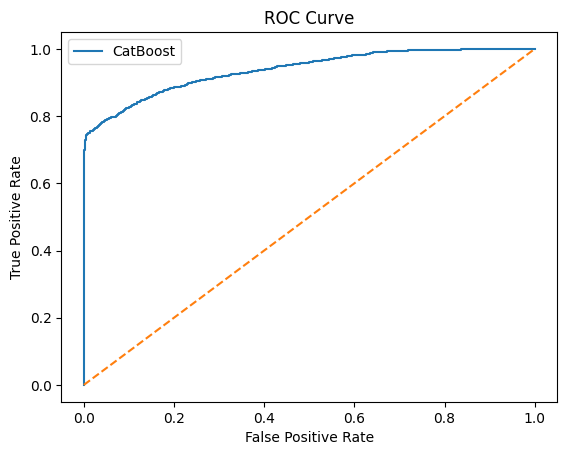

In [ ]:
plt.figure()
results = {
    # "Random Forest": {"model": model_rf_best},
    # "Gradient Boosting": {"model": gb},
    "CatBoost": {"model": model_cat},
}
for name, res in results.items():
    probs = res["model"].predict_proba(x_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

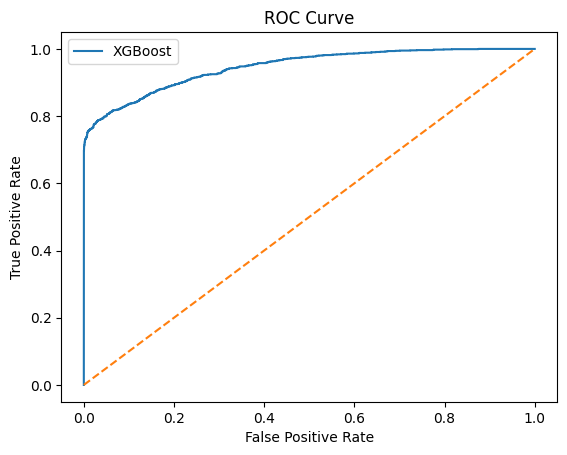

In [ ]:
plt.figure()
results = {
    "XGBoost": {"model": model_xgb}
}
for name, res in results.items():
    probs = res["model"].predict_proba(x_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

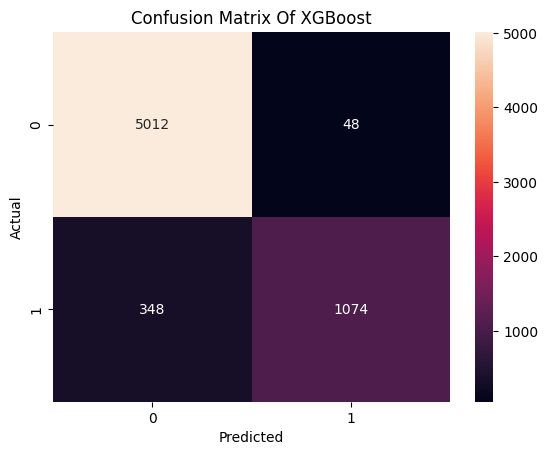

In [ ]:
preds = model_xgb.predict(x_test)

cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix Of XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

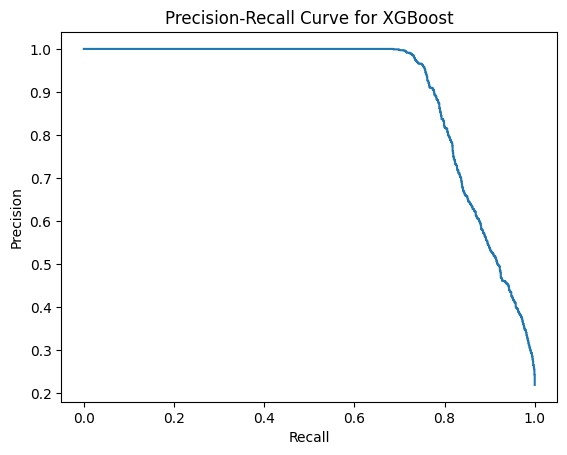

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, probs)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve for XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)

In [ ]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),

    # Distance-based
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    "SVC": SVC(probability=True, random_state=1),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

In [ ]:
results = {}

for name, model in tqdm(models.items()):
    model.fit(x_train_smote, y_train_smote)

    train_pred = model.predict(x_train_smote)
    test_pred  = model.predict(x_test)

    y_pred_prob = model.predict_proba(x_test)[:, 1]
    
   

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    
    results[name] = {
        "Train Accuracy": accuracy_score(y_train_smote, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train_smote, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train_smote, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train_smote, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train_smote, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
        

    }
    

 92%|█████████▏| 12/13 [07:13<00:12, 12.12s/it]

[LightGBM] [Info] Number of positive: 20261, number of negative: 20261
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001812 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3056
[LightGBM] [Info] Number of data points in the train set: 40522, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


100%|██████████| 13/13 [07:14<00:00, 33.39s/it]


In [ ]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("nb", models["Naive Bayes"]),
        ("xgb", models["XGBoost"]),
    ],
    voting="soft" # voting='hard' / voting='soft', weights=[2, 1, 2,1]
)

voting_model.fit(x_train_smote, y_train_smote)
voting_train_pred = voting_model.predict(x_train_smote)
voting_test_pred = voting_model.predict(x_test)



results["Voting Classifier"] = {
    "Train Accuracy": accuracy_score(y_train_smote, voting_train_pred),
    "Test Accuracy": accuracy_score(y_test, voting_test_pred),
    "Train Precision": precision_score(y_train_smote, voting_train_pred),
    "Test Precision": precision_score(y_test, voting_test_pred),
    "Train Recall": recall_score(y_train_smote, voting_train_pred),
    "Test Recall": recall_score(y_test, voting_test_pred),
    "Train F1 Score": f1_score(y_train_smote, voting_train_pred),
    "Test F1 Score": f1_score(y_test, voting_test_pred),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train_smote, voting_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, voting_test_pred),
  
}

In [ ]:
stack_auto = StackingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("nb", models["Naive Bayes"]),
        ("lgbm", models["LightGBM"]),

        
    ],
    final_estimator=XGBClassifier(max_iter=2000),
    stack_method="predict_proba",   # best for classification usually
    n_jobs=-1
)

# Train
stack_auto.fit(x_train_smote, y_train_smote)

# Predictions
stack_auto_train_pred = stack_auto.predict(x_train_smote)
stack_auto_test_pred  = stack_auto.predict(x_test)

results["Stacking Classifier "] = {
    "Train Accuracy": accuracy_score(y_train_smote, stack_auto_train_pred),
    "Test Accuracy": accuracy_score(y_test, stack_auto_test_pred),
    "Train Precision": precision_score(y_train_smote, stack_auto_train_pred),
    "Test Precision": precision_score(y_test, stack_auto_test_pred),
    "Train Recall": recall_score(y_train_smote, stack_auto_train_pred),
    "Test Recall": recall_score(y_test, stack_auto_test_pred),
    "Train F1 Score": f1_score(y_train_smote, stack_auto_train_pred),
    "Test F1 Score": f1_score(y_test, stack_auto_test_pred),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train_smote, stack_auto_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, stack_auto_test_pred),
}

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [ ]:
results_df.sort_values(by="Test F1 Score", ascending=False)

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
CatBoost,0.965451,0.940450,0.997520,0.970054,0.933221,0.751758,0.964300,0.847068,0.965451,0.872618
LightGBM,0.956517,0.938136,0.996351,0.969641,0.916391,0.741210,0.954700,0.840175,0.956517,0.867344
Hist Gradient Boosting,0.954963,0.938136,0.995645,0.972248,0.913923,0.739100,0.953035,0.839792,0.954963,0.866586
XGBoost,0.968116,0.934125,0.997274,0.938326,0.938799,0.748945,0.967153,0.833007,0.968116,0.867556
Stacking Classifier,0.998075,0.931194,0.998173,0.923611,0.997976,0.748242,0.998075,0.826729,0.998075,0.865425
Random Forest,1.000000,0.928417,1.000000,0.912220,1.000000,0.745429,1.000000,0.820433,1.000000,0.862635
Gradient Boosting,0.911850,0.908053,0.952644,0.817204,0.866788,0.748242,0.907691,0.781204,0.911850,0.850603
Extra Trees,1.000000,0.911910,1.000000,0.859072,1.000000,0.715893,1.000000,0.780974,1.000000,0.841445
Voting Classifier,0.948497,0.885838,0.952991,0.723753,0.943537,0.775668,0.948240,0.748812,0.948497,0.846233
SVC,0.841938,0.869176,0.889388,0.679825,0.781008,0.763010,0.831682,0.719019,0.841938,0.831011


<Axes: >

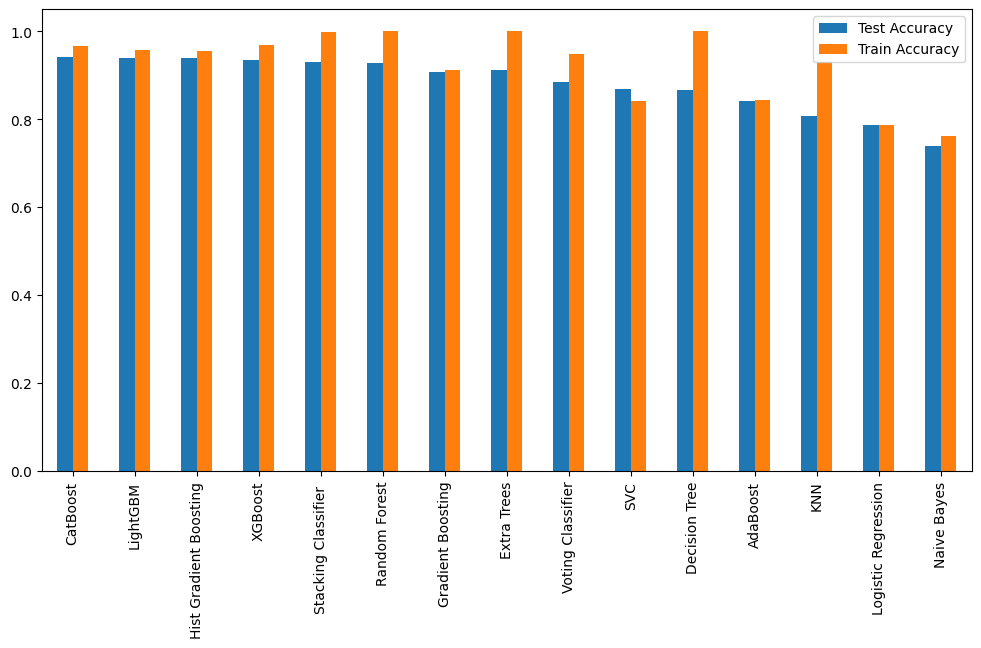

In [ ]:
results_df[["Test Accuracy", "Train Accuracy"]].plot.bar(figsize=(12,6))

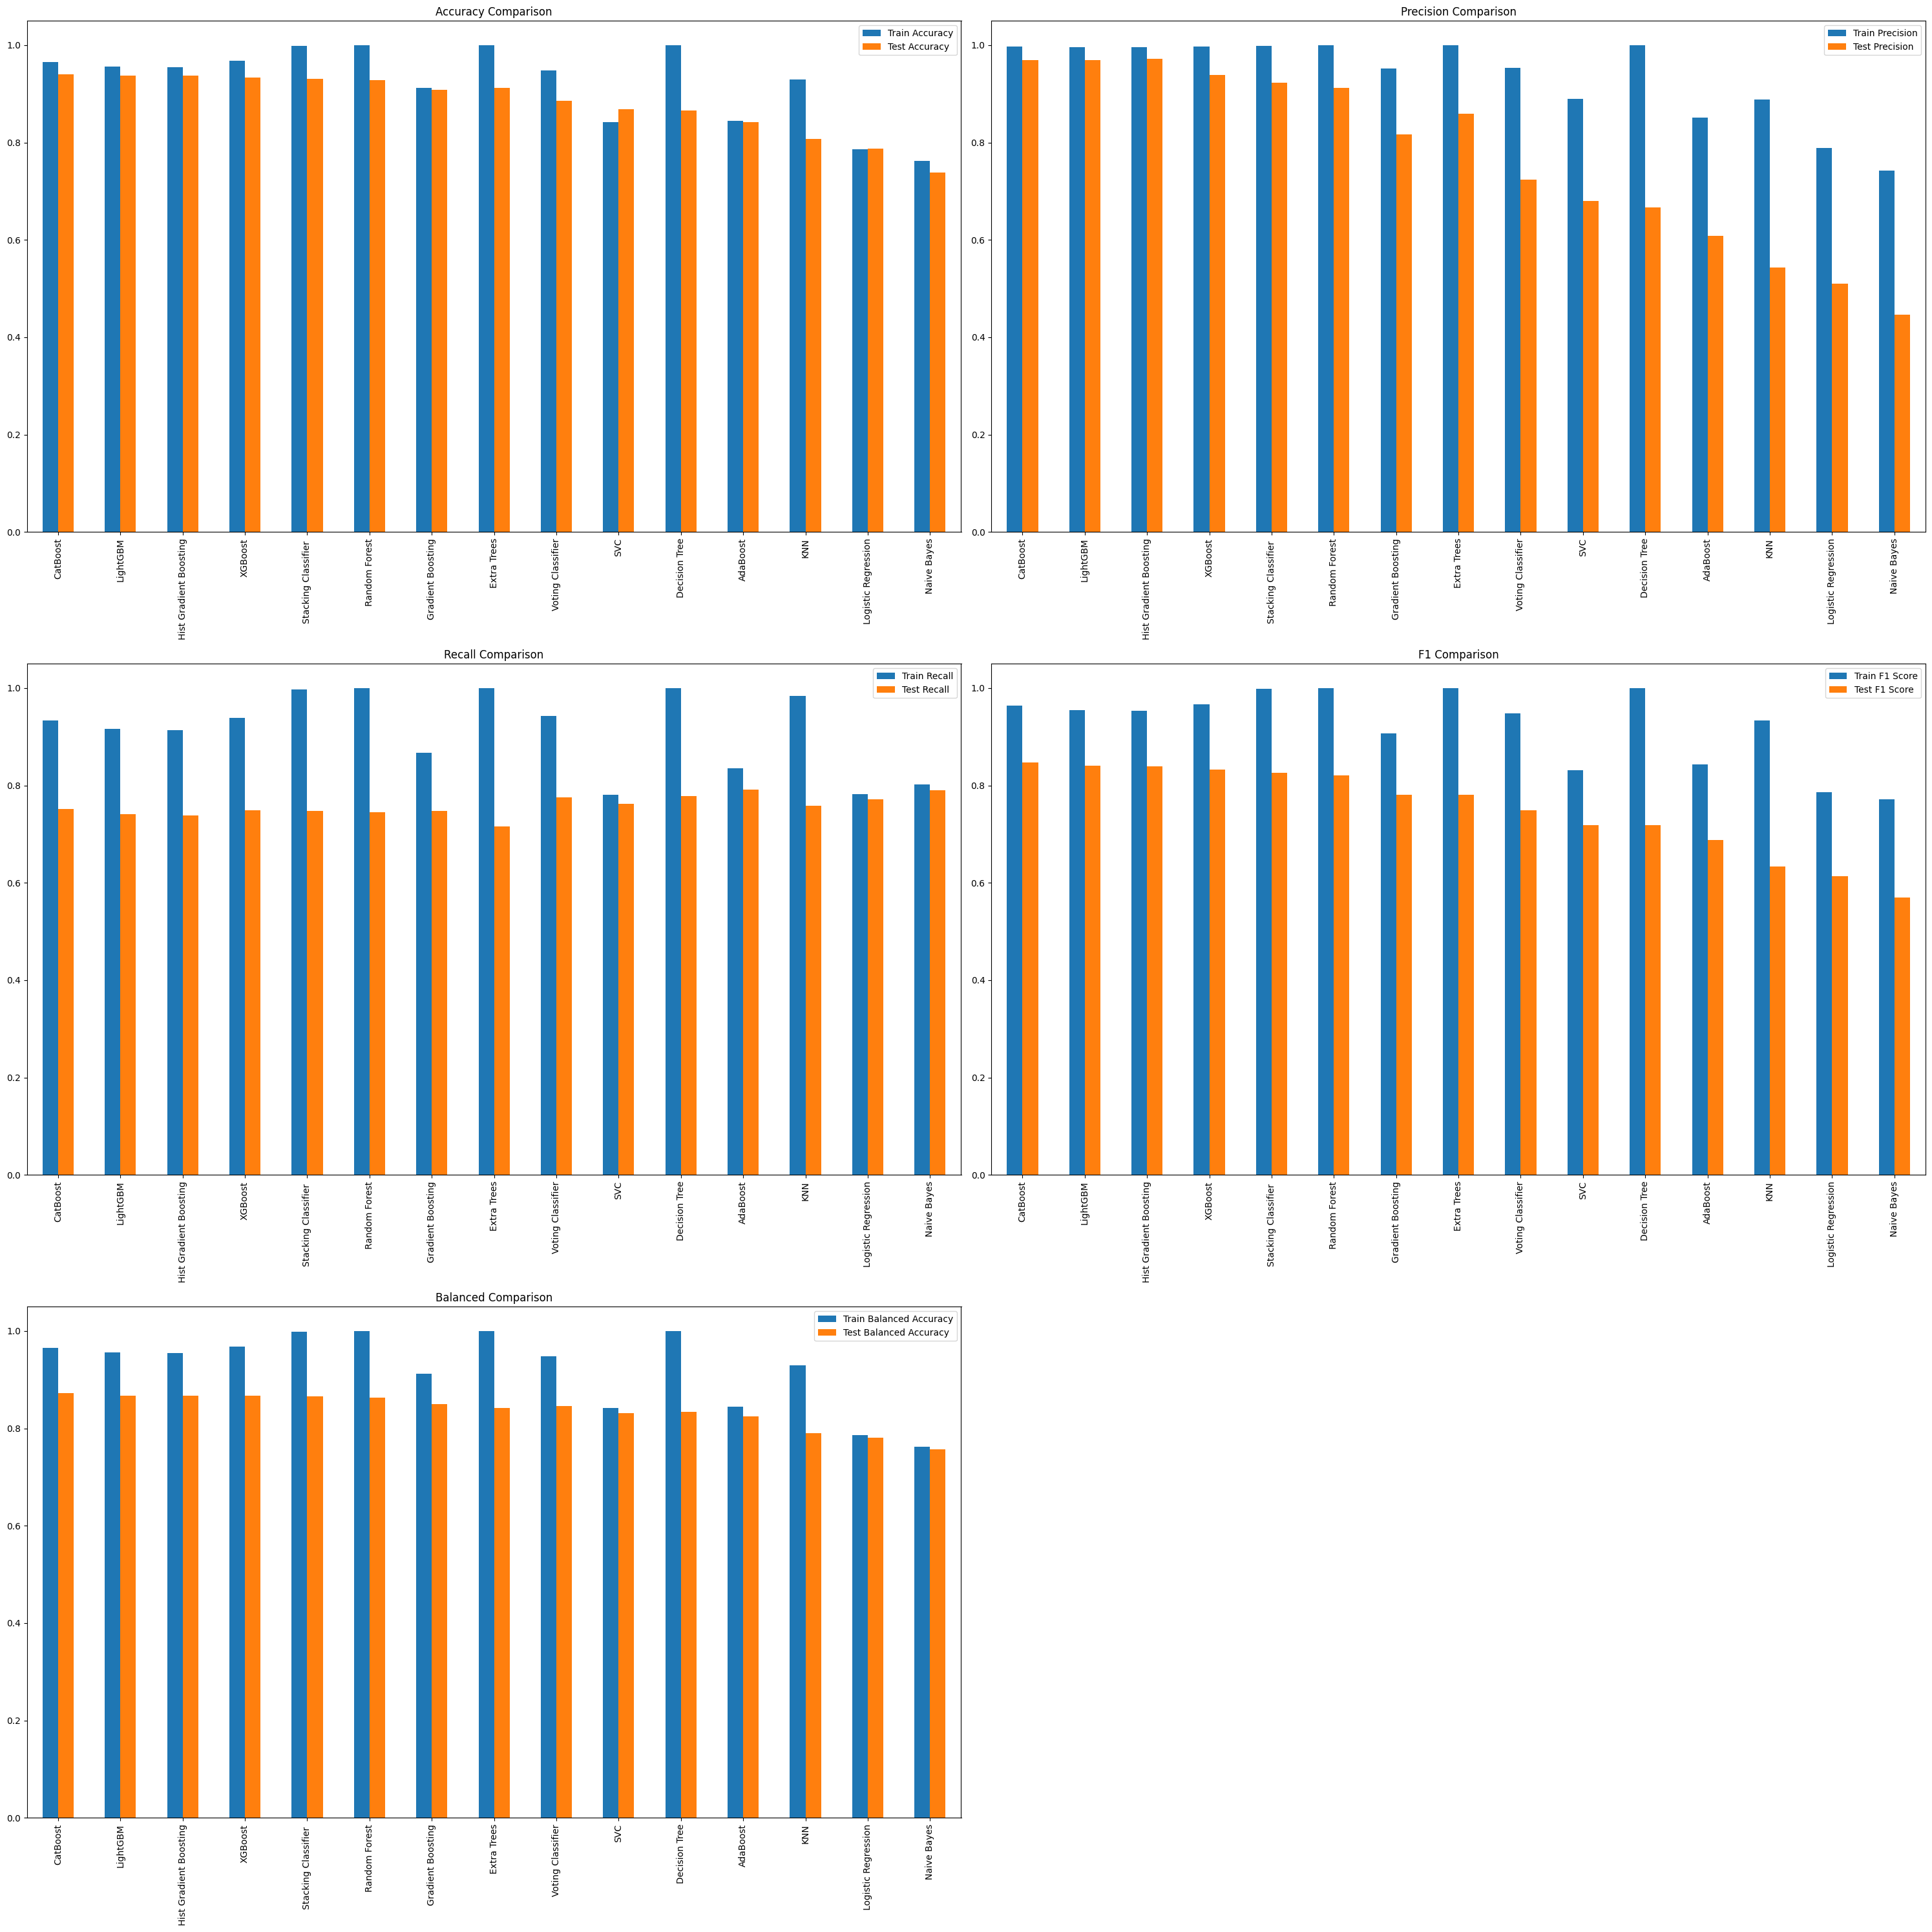

In [ ]:
cols = [
    ['Train Accuracy', 'Test Accuracy'],
    ['Train Precision', 'Test Precision'],
    ['Train Recall', 'Test Recall'],
    ['Train F1 Score', 'Test F1 Score'],
    ["Train Balanced Accuracy", "Test Balanced Accuracy"]
]

plt.figure(figsize=(30,30))

for i, col in enumerate(cols):
    ax = plt.subplot(3, 2, i+1)   
    results_df[col].plot.bar(ax=ax)   
    ax.set_title(col[0].split(" ")[1] + ' Comparison')

plt.tight_layout()
plt.show()